## 1. Importación de librerías

# Sistema de Recomendación de Productos
## Joyería Diana Laura — Content-Based Filtering (Similitud Coseno)

Este notebook implementa un sistema de recomendación basado en contenido.
El objetivo es recomendar productos similares al que el cliente acaba de comprar o está viendo,
comparando sus características físicas y de fabricación mediante similitud coseno.

In [1]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from dotenv import load_dotenv

load_dotenv()
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 2. Conexión a la base de datos

In [2]:
DATABASE_URL = os.getenv('DATABASE_URL')

conn = psycopg2.connect(DATABASE_URL)
print('✅ Conexión exitosa a Supabase')

✅ Conexión exitosa a Supabase


## 3. Extracción de productos

In [3]:
query = """
    SELECT
        p.id,
        p.nombre,
        p.material_principal,
        c.nombre AS categoria,
        p.peso_gramos,
        p.dias_fabricacion,
        p.permite_personalizacion
    FROM productos p
    JOIN categorias c ON p.categoria_id = c.id
    WHERE p.activo = true
    ORDER BY p.id
"""

df = pd.read_sql(query, conn)
print(f'✅ Total de productos obtenidos: {len(df)}')
df

C:\Users\uriel\AppData\Local\Temp\ipykernel_29904\3722298894.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


✅ Total de productos obtenidos: 15


,id,nombre,material_principal,categoria,peso_gramos,dias_fabricacion,permite_personalizacion
0,1,Esclava personalizada Día del Padre,Plata,esclavas,6.2,0,True
1,2,Aretes corazón doble plata,Plata,Aretes,2.5,0,False
2,3,Pulsera personalizada Día del Niño,Acero/cuentas plásticas (bisutería),Pulseras,1.5,0,True
3,4,Esclava laminado de oro figaro,Laminado de oro,esclavas,12.5,0,False
4,6,Anillo plata solitario clásico,Plata,Anillos,4.5,0,False
5,8,Anillo plata piedra corazón rosa,Plata,Anillos,4.8,0,False
6,9,Anillo plata ley .925 corazón amatista,Plata ley .925,Anillos,5.5,0,False
7,10,Aretes plata ley .925 cristal azul y corazón f...,Plata ley .925,Aretes,3.0,0,False
8,11,Aretitos plata corazón filigrana morado,Plata,Aretes,2.1,0,False
9,12,Aretitos plata gota filigrana con perla,Plata,Aretes,2.3,0,False


## 4. Exploración de datos

In [4]:
print('=== RESUMEN DE DATOS ===')
print(f'Total de productos: {len(df)}')
print()
print('=== MATERIALES ===')
print(df['material_principal'].value_counts())
print()
print('=== CATEGORÍAS ===')
print(df['categoria'].value_counts())
print()
print('=== ESTADÍSTICAS NUMÉRICAS ===')
print(df[['peso_gramos', 'dias_fabricacion']].describe())

=== RESUMEN DE DATOS ===
Total de productos: 15

=== MATERIALES ===
material_principal
Plata                                  6
Plata ley .925                         4
Chapa de oro                           2
Acero/cuentas plásticas (bisutería)    1
Laminado de oro                        1
Baño en rodio                          1
Name: count, dtype: int64

=== CATEGORÍAS ===
categoria
Anillos     8
Aretes      4
esclavas    2
Pulseras    1
Name: count, dtype: int64

=== ESTADÍSTICAS NUMÉRICAS ===
       peso_gramos  dias_fabricacion
count    15.000000              15.0
mean      4.466667               0.0
std       2.650247               0.0
min       1.500000               0.0
25%       2.750000               0.0
50%       4.100000               0.0
75%       5.350000               0.0
max      12.500000               0.0


## 5. Preparación de variables (codificación)

In [5]:
df_features = df.copy()

# Codificar variables categóricas con LabelEncoder
le_material = LabelEncoder()
le_categoria = LabelEncoder()

df_features['material_enc'] = le_material.fit_transform(df['material_principal'])
df_features['categoria_enc'] = le_categoria.fit_transform(df['categoria'])
df_features['personalizacion_enc'] = df['permite_personalizacion'].astype(int)

# Matriz de características para similitud coseno
feature_cols = ['material_enc', 'categoria_enc', 'peso_gramos', 'dias_fabricacion', 'personalizacion_enc']
X = df_features[feature_cols].values

print('=== VARIABLES CODIFICADAS ===')
print(df_features[['nombre', 'material_enc', 'categoria_enc', 'peso_gramos', 'dias_fabricacion', 'personalizacion_enc']])
print(f'\nDimensiones de la matriz de características: {X.shape}')

=== VARIABLES CODIFICADAS ===
                                               nombre  material_enc  \
0                 Esclava personalizada Día del Padre             4   
1                          Aretes corazón doble plata             4   
2                  Pulsera personalizada Día del Niño             0   
3                      Esclava laminado de oro figaro             3   
4                      Anillo plata solitario clásico             4   
5                    Anillo plata piedra corazón rosa             4   
6              Anillo plata ley .925 corazón amatista             5   
7   Aretes plata ley .925 cristal azul y corazón f...             5   
8             Aretitos plata corazón filigrana morado             4   
9             Aretitos plata gota filigrana con perla             4   
10        Anillo de promesa piedra rosa baño en rodio             1   
11          Anillo dorado diseño floral con circonias             2   
12  Anillo oro amarillo diseño enredadera con c

## 6. Cálculo de Similitud Coseno

In [6]:
sim_matrix = cosine_similarity(X)

sim_df = pd.DataFrame(sim_matrix, index=df['nombre'], columns=df['nombre'])

print(f'Dimensiones de la matriz de similitud: {sim_matrix.shape}')
print('(Cada celda indica qué tan similar es un producto con otro — 1.0 = idéntico)')
print()
print(sim_df.round(2))

Dimensiones de la matriz de similitud: (15, 15)
(Cada celda indica qué tan similar es un producto con otro — 1.0 = idéntico)

nombre                                              Esclava personalizada Día del Padre  \
nombre                                                                                    
Esclava personalizada Día del Padre                                                1.00   
Aretes corazón doble plata                                                         0.89   
Pulsera personalizada Día del Niño                                                 0.75   
Esclava laminado de oro figaro                                                     0.93   
Anillo plata solitario clásico                                                     0.91   
Anillo plata piedra corazón rosa                                                   0.91   
Anillo plata ley .925 corazón amatista                                             0.91   
Aretes plata ley .925 cristal azul y corazón fi...     

## 7. Visualización — Mapa de Calor de Similitud

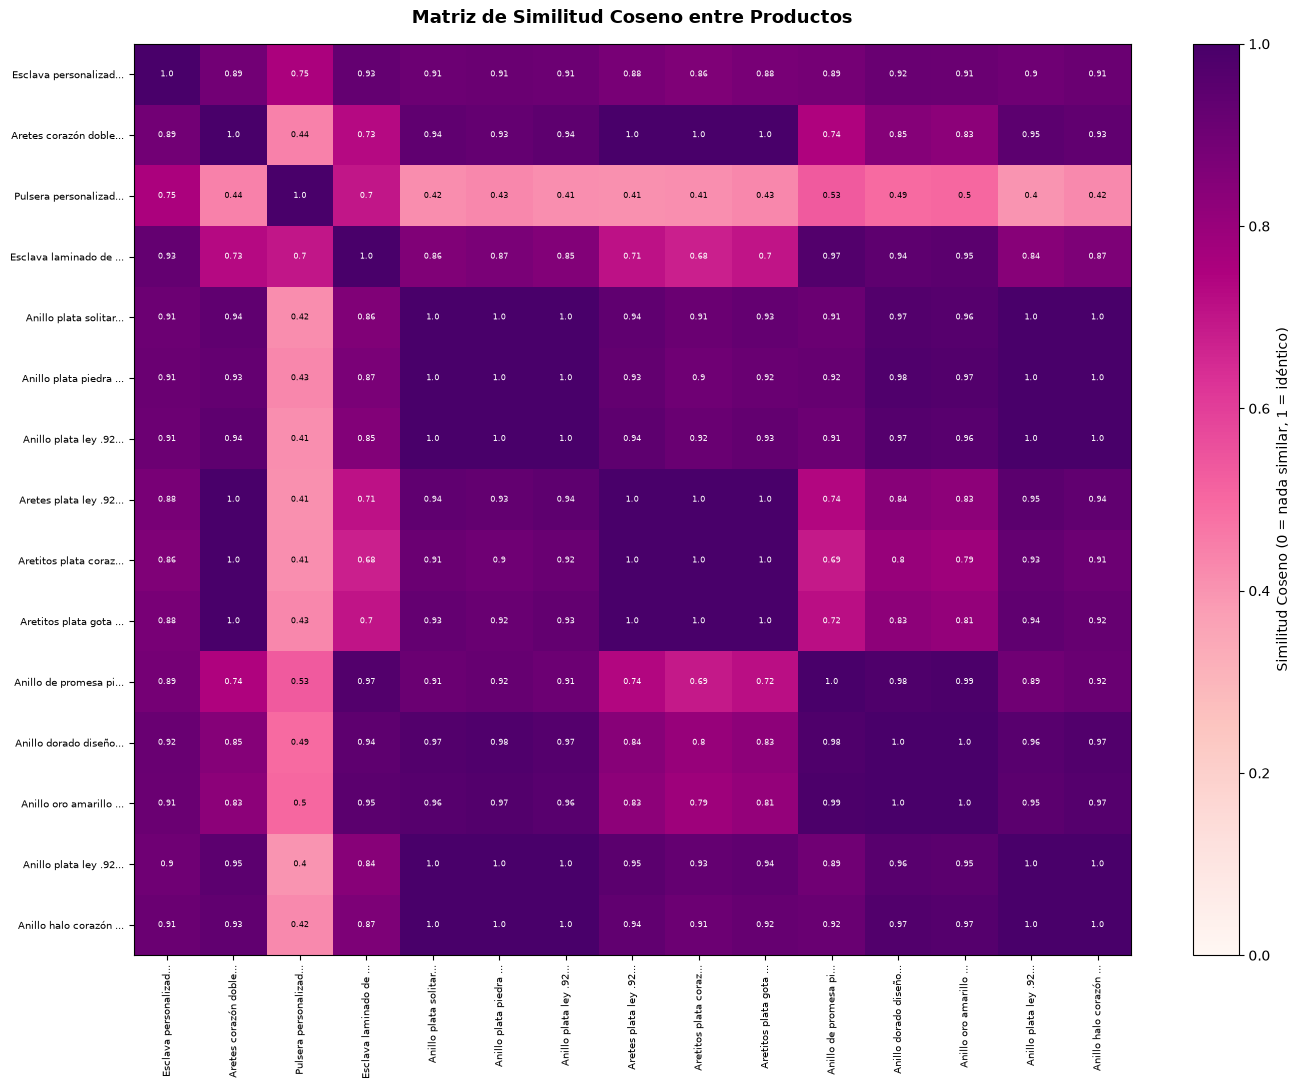

In [7]:
fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(sim_matrix, cmap='RdPu', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, label='Similitud Coseno (0 = nada similar, 1 = idéntico)')

nombres_cortos = [n[:20] + '...' if len(n) > 20 else n for n in df['nombre']]
ax.set_xticks(range(len(df)))
ax.set_yticks(range(len(df)))
ax.set_xticklabels(nombres_cortos, rotation=90, fontsize=7)
ax.set_yticklabels(nombres_cortos, fontsize=7)

for i in range(len(df)):
    for j in range(len(df)):
        val = round(sim_matrix[i, j], 2)
        color = 'white' if sim_matrix[i, j] > 0.6 else 'black'
        ax.text(j, i, str(val), ha='center', va='center', fontsize=6, color=color)

ax.set_title('Matriz de Similitud Coseno entre Productos', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 8. Sistema de Recomendación

In [8]:
def recomendar(producto_id, df, sim_matrix, top_n=3):
    """
    Recomienda los productos más similares a un producto dado.
    producto_id: id del producto comprado/visto
    """
    # Encontrar el índice del producto en el dataframe
    indices = df[df['id'] == producto_id].index
    if len(indices) == 0:
        return []
    idx = indices[0]

    # Obtener similitudes con todos los demás productos
    similitudes = list(enumerate(sim_matrix[idx]))

    # Ordenar por similitud descendente, excluyendo el mismo producto
    similitudes = sorted(similitudes, key=lambda x: x[1], reverse=True)
    similitudes = [s for s in similitudes if s[0] != idx]

    # Retornar los top_n más similares
    top_indices = [s[0] for s in similitudes[:top_n]]
    resultado = df.iloc[top_indices][['id', 'nombre', 'material_principal', 'categoria']].copy()
    resultado['similitud'] = [round(similitudes[i][1], 4) for i in range(len(top_indices))]
    return resultado

print('✅ Función de recomendación lista')

✅ Función de recomendación lista


## 9. Prueba del sistema de recomendación

## 10. Guardar el modelo

In [9]:
# Prueba 1 — recomendar a partir del primer producto del catálogo
primer_id = df.iloc[0]['id']
primer_nombre = df.iloc[0]['nombre']
print(f'Producto visto: "{primer_nombre}"')
print()
recomendaciones = recomendar(primer_id, df, sim_matrix)
print('Recomendaciones:')
print(recomendaciones.to_string(index=False))
print()

# Prueba 2 — recomendar a partir del segundo producto
segundo_id = df.iloc[1]['id']
segundo_nombre = df.iloc[1]['nombre']
print(f'Producto visto: "{segundo_nombre}"')
print()
recomendaciones2 = recomendar(segundo_id, df, sim_matrix)
print('Recomendaciones:')
print(recomendaciones2.to_string(index=False))

Producto visto: "Esclava personalizada Día del Padre"

Recomendaciones:
 id                                              nombre material_principal categoria  similitud
  4                      Esclava laminado de oro figaro    Laminado de oro  esclavas     0.9295
 14           Anillo dorado diseño floral con circonias       Chapa de oro   Anillos     0.9155
 15 Anillo oro amarillo diseño enredadera con circonias       Chapa de oro   Anillos     0.9126

Producto visto: "Aretes corazón doble plata"

Recomendaciones:
 id                                                 nombre material_principal categoria  similitud
 12                Aretitos plata gota filigrana con perla              Plata    Aretes     0.9993
 10 Aretes plata ley .925 cristal azul y corazón filigrana     Plata ley .925    Aretes     0.9991
 11                Aretitos plata corazón filigrana morado              Plata    Aretes     0.9973


In [10]:
modelo = {
    'sim_matrix': sim_matrix,
    'df_productos': df,
    'le_material': le_material,
    'le_categoria': le_categoria,
    'feature_cols': feature_cols
}

with open('modelo_recomendacion.pkl', 'wb') as f:
    pickle.dump(modelo, f)

print('✅ Modelo guardado como modelo_recomendacion.pkl')

✅ Modelo guardado como modelo_recomendacion.pkl


## 11. Conclusiones

El sistema de recomendación basado en **Content-Based Filtering con Similitud Coseno** fue implementado exitosamente para Joyería Diana Laura.

**¿Por qué Content-Based Filtering?**
En una joyería los clientes generalmente compran 1 pieza por visita, lo que hace que las reglas de asociación (Apriori) no sean adecuadas al requerir múltiples productos por transacción. Content-Based Filtering resuelve esto comparando los atributos de los productos entre sí, sin depender de cuántos artículos se compren juntos.

**Variables utilizadas (X):**
- `material_principal` — el material define características físicas y de precio
- `categoria` — aretes, anillos, esclavas, pulseras
- `peso_gramos` — cantidad de material utilizado
- `dias_fabricacion` — complejidad del producto
- `permite_personalizacion` — si requiere trabajo adicional

**Cómo funciona:**
1. Cada producto se representa como un vector de características numéricas
2. La similitud coseno mide el ángulo entre dos vectores — entre más cercano a 1, más similares son los productos
3. Cuando un cliente compra o ve un producto, el sistema devuelve los N productos con mayor similitud

**Siguiente paso:** El modelo fue exportado como `modelo_recomendacion.pkl` y será consumido por el microservicio Flask para integrarse con la plataforma web de Joyería Diana Laura.